# EPFL microgrid: validation against EMTP-RV

The EPFL 26-bus hybrid AC/DC microgrid (paper section IV-A) was simulated in **EMTP-RV**, a detailed
time-domain simulation that includes the converters and their control loops
([EMTP-RV model](https://github.com/DESL-EPFL/Hybrid_ACDC_EMTP_simulation)). This notebook takes the steady state
of that simulation as the reference:
- the power flow gets the injections measured in EMTP-RV as setpoints;
- its voltages must match the voltages measured in EMTP-RV.

This repeats the balanced validation of the paper (W. Lambrichts and M. Paolone, IEEE Trans. Power Systems, 2024, [doi:10.1109/TPWRS.2024.3378926](https://doi.org/10.1109/TPWRS.2024.3378926)).
Its Table III reports a largest voltage error of 7.4e-6 p.u. (AC) and 5.9e-8 p.u. (DC).

As in the paper, the errors are Δ = EMTP-RV − power flow, per bus: ΔE for the nodal voltages and ΔP (ΔQ) for the
nodal injections, where the power flow's injections are computed from its own voltages. At buses where P is a
setpoint, ΔP is zero by construction; the informative values are at the slack (B01) and at the converters that
hold the DC voltage (AC side B16, B18; DC side B20, B22).

| | |
|---|---|
| AC buses | 18 (17 lines) |
| DC buses | 8, in 1 DC grid |
| Converters | 4: 2 × PQ (fixed P and Q), 2 × VdcQ (holds its DC voltage, fixed Q) |
| Case file | `validation/cases/microgrid_emtp.yaml` |
| EMTP-RV reference | `validation/emtp/emtp_balanced.csv` (phase a of the AC buses; the case is balanced) |

The setpoints follow the paper:
- the slack voltage at B01, and the loads at B03, B05, B11 and B13;
- the DC injections at B23–B26: two sources and two loads of 5 kW;
- two converters in PQ mode (measured P and Q, plus the small measured difference between their AC and DC power
  as a constant loss);
- two converters in VdcQ mode (measured DC voltage and Q).

`validation/emtp/make_emtp_case.py` shows how the case and the reference were made from the data of the paper.

## Grid topology

![Grid topology](figures/microgrid.png)

## Running this notebook

Use the kernel **Python 3.12 (unified-acdc-powerflow)** (VS Code: *Select Kernel* → *Jupyter Kernel…*). To set it
up once, in the repository folder:

```bash
python3.12 -m venv .venv
.venv/bin/pip install -e ".[dev]"
.venv/bin/python -m ipykernel install --user --name unified-acdc-powerflow --display-name "Python 3.12 (unified-acdc-powerflow)"
```


In [1]:
import logging, warnings
logging.getLogger("pandapower").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from unified_acdc_powerflow import build_model, build_ybus, solve
from unified_acdc_powerflow.cases import CASE_DIR, load_case

# 1) load the case (EMTP-RV setpoints) and the EMTP-RV reference
net = load_case("microgrid_emtp")
emtp = pd.read_csv(CASE_DIR.parent / "emtp" / "emtp_balanced.csv")
model = build_model(net)
print(f"{model.n_ac} AC nodes, {model.n_dc} DC nodes, {model.n_conv} converters")
emtp


18 AC nodes, 8 DC nodes, 4 converters


,bus,side,E_re_pu,E_im_pu,P_pu,Q_pu
0,B01,AC,1.000000,-1.183948e-09,9.405075e-01,-3.439228e-01
1,B02,AC,0.990604,-9.004772e-03,0.000000e+00,0.000000e+00
2,B03,AC,0.971491,-9.627963e-03,-3.000001e-01,-9.425143e-05
3,B04,AC,0.987752,-1.271954e-02,0.000000e+00,0.000000e+00
4,B05,AC,0.981991,-1.242763e-02,-3.749766e-01,-7.511781e-02
5,B06,AC,0.985940,-2.100600e-02,0.000000e+00,0.000000e+00
6,B07,AC,0.985422,-2.337339e-02,0.000000e+00,0.000000e+00
7,B08,AC,0.984246,-2.182580e-02,0.000000e+00,0.000000e+00
8,B09,AC,0.984550,-2.231191e-02,-1.551741e-07,-1.718092e-15
9,B10,AC,0.967771,-4.176449e-02,0.000000e+00,0.000000e+00


In [2]:
# 2) build Y (AC: pandapower Ybus with taps and shunts; DC: conductance matrix G)
build_ybus(model)
print("Y (AC):", model.Y.shape, "nnz", model.Y.nnz)
print("G (DC):", model.G.shape, "nnz", model.G.nnz)


Y (AC): (18, 18) nnz 52
G (DC): (8, 8) nnz 22


In [3]:
# 3) Newton-Raphson
res = solve(model, tol=1e-10)
print(res.message, "| iterations:", res.iterations, "| max mismatch:", f"{res.max_mismatch:.2e}",
      "| time:", f"{res.solve_time_s * 1e3:.1f} ms")


converged | iterations: 5 | max mismatch: 7.03e-14 | time: 47.2 ms


In [4]:
# 4) compare with EMTP-RV as in the paper (section IV-A): delta = EMTP-RV - power flow, per bus
#    E: nodal voltage; P, Q: nodal injection computed by the power flow from its voltages (DC buses: P only)
m = res.model
ac = emtp.side == "AC"
E_pf = np.array([res.E_ac[m.bus_lookup[int(b[1:])]] if a else res.E_dc[m.bus_dc_lookup[int(b[1:])]]
                 for b, a in zip(emtp.bus, ac)])
S_pf = np.array([res.S_ac[m.bus_lookup[int(b[1:])]] if a else res.P_dc[m.bus_dc_lookup[int(b[1:])]]
                 for b, a in zip(emtp.bus, ac)])
dE = (emtp.E_re_pu + 1j * emtp.E_im_pu).values - E_pf
dS = (emtp.P_pu + 1j * emtp.Q_pu).values - S_pf
delta = pd.DataFrame({"bus": emtp.bus, "side": emtp.side, "dE_re (p.u.)": dE.real, "dE_im (p.u.)": dE.imag,
                      "dP (p.u.)": dS.real, "dQ (p.u.)": np.where(ac, dS.imag, np.nan)})

# summary as in Table III of the paper: mean and max of |dE| and |dP| per grid
paper = {"AC": (2.76e-6, 7.36e-6), "DC": (1.54e-8, 5.88e-8)}
summary = pd.DataFrame([{"grid": g,
                         "|dE| mean": np.abs(dE[emtp.side == g]).mean(), "|dE| max": np.abs(dE[emtp.side == g]).max(),
                         "paper |dE| mean": paper[g][0], "paper |dE| max": paper[g][1],
                         "|dP| mean": np.abs(dS.real[emtp.side == g]).mean(), "|dP| max": np.abs(dS.real[emtp.side == g]).max()}
                        for g in ("AC", "DC")])
display(summary)
delta


,grid,|dE| mean,|dE| max,paper |dE| mean,paper |dE| max,|dP| mean,|dP| max
0,AC,1.741075e-06,3.333954e-06,2.760000e-06,7.360000e-06,3.720871e-06,3.448664e-05
1,DC,1.108009e-08,3.248613e-08,1.540000e-08,5.880000e-08,1.462276e-08,6.049951e-08


,bus,side,dE_re (p.u.),dE_im (p.u.),dP (p.u.),dQ (p.u.)
0,B01,AC,-2.020606e-13,8.466194e-22,-3.448664e-05,-5.784539e-07
1,B02,AC,3.945967e-07,1.940049e-07,-2.809067e-14,7.294600e-15
2,B03,AC,4.026384e-07,1.899783e-07,1.054712e-14,1.857238e-16
3,B04,AC,5.948245e-07,2.801388e-07,6.950609e-15,-5.354175e-15
4,B05,AC,5.981735e-07,2.778973e-07,-1.221800e-13,6.702972e-15
5,B06,AC,1.934922e-06,4.107633e-07,7.024167e-15,7.264291e-16
6,B07,AC,2.317550e-06,4.480841e-07,-5.667895e-14,-2.667866e-14
7,B08,AC,1.005383e-06,3.672620e-07,-7.028859e-14,-1.440304e-14
8,B09,AC,1.002062e-06,3.691104e-07,4.043571e-14,-2.511162e-14
9,B10,AC,2.374902e-06,4.848843e-07,6.876412e-15,-2.967580e-16


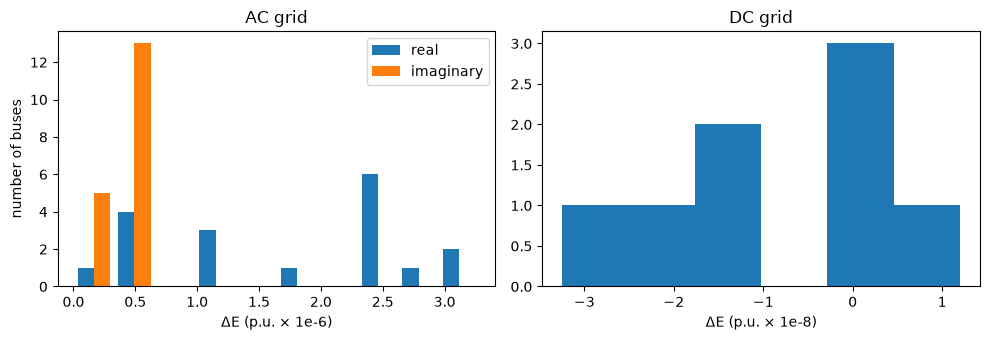

In [5]:
# 5) histograms of the voltage errors, as in Fig. 5 of the paper
import matplotlib.pyplot as plt

fig, (ax_ac, ax_dc) = plt.subplots(1, 2, figsize=(10, 3.5))
ax_ac.hist([dE[ac].real * 1e6, dE[ac].imag * 1e6], bins=10, label=["real", "imaginary"])
ax_ac.set(title="AC grid", xlabel="ΔE (p.u. × 1e-6)", ylabel="number of buses")
ax_ac.legend()
ax_dc.hist(dE[~ac].real * 1e8, bins=6)
ax_dc.set(title="DC grid", xlabel="ΔE (p.u. × 1e-8)")
plt.tight_layout()
